# The Bosonic Binary Solver — what it is, and what makes it work

A reproduction of **[arXiv:2510.08274](https://arxiv.org/abs/2510.08274)**, *A Binary
Optimisation Algorithm for Near-Term Photonic Quantum Processors* (Makarovskiy et al.,
ORCA Computing / PSNC / Poznań University of Technology).

**Read this notebook to learn:** how a photonic time-bin processor is turned into a
combinatorial optimiser, whether the paper's claims hold up, and — the part that took the
most work to establish — *which component of the algorithm is actually doing the work*.

Everything here runs on a laptop CPU in a few minutes. Where a full-scale result is quoted,
it comes from the 3 800 GPU runs in `results/` and is labelled as such; the live cells are
small-size demonstrations, labelled `demo`.

## 1. The problem the paper attacks

Binary optimisation — knapsack, routing, scheduling — means minimising a cost `C(x)` over
`x ∈ {0,1}^m`. The space is `2^m`, so at `m = 30` there are a billion candidates.

The paper's machine is ORCA's **PT-Series**: a train of `m` optical pulses ("time bins"),
each either carrying a single photon or empty, passing through programmable fibre **delay
lines**. A pulse entering a delay of length `ℓ` comes back `ℓ` bins later and interferes
with whatever is passing then. Detectors at the end report, for each bin, whether at least
one photon arrived — a **threshold** measurement. That gives one bit per bin: a candidate
solution, sampled from a distribution the interferometer's beamsplitter angles control.

The algorithm, then:

1. sample `S` bit strings from the photonic circuit at the current angles `θ`;
2. flip bit `i` independently with a **trainable** probability `p_i` — this is what lets the
   distribution reach strings the interferometer alone cannot favour;
3. estimate `∂E[C(X)]/∂θ` with a photonic **parameter-shift rule** and `∂E[C(X)]/∂p` analytically;
4. take a plain SGD step, and keep the best candidate ever evaluated.

The claim is that this finds optima for problems up to `m = 30` while evaluating only a
sliver of the space, and that it runs on real hardware today.

In [1]:
import sys, time, math, json, collections
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (7.2, 3.4), "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {"boson": "#4C6EF5", "classical": "#F08C00", "control": "#868E96", "accent": "#12B886"}
print("ready")

ready


## 2. What this reproduction tests, and what it does not

The paper makes seven material claims. Each was written down *before* any experiment, together
with the confounder that could fake it — that discipline is what makes the headline result
below trustworthy rather than a story fitted to the data afterwards.

In [2]:
claims = [
    ("C1", "Solves knapsack and TSP up to m=30",        "Table I",      "reproduced (one gap at m=30)"),
    ("C2", "Competitive with simulated annealing / hill climbing", "Table I", "tested at MATCHED budget"),
    ("C3", "Evaluates only ~2.15e6 of 2^30 candidates", "Appendix B",   "exact, and now an anchor test"),
    ("C4", "Transfers to TSP",                          "Table I",      "reproduced and exceeded"),
    ("C5", "The photonic sampler is what makes it work","the premise",  "NOT SUPPORTED"),
    ("C6", "Runs on PT-1 hardware",                     "Table II",     "blocked: no hardware"),
    ("C7", "The trainable circuit matters",             "Sec. V",       "strongly supported"),
]
width = max(len(c[1]) for c in claims)
print(f"{'ID':<4}{'claim':<{width+2}}{'evidence':<14}{'verdict'}")
print("-" * (width + 52))
for cid, claim, evidence, verdict in claims:
    print(f"{cid:<4}{claim:<{width+2}}{evidence:<14}{verdict}")
print("\nNot implemented: tactical deconfliction (5 of Table I's 13 rows) -- the paper gives")
print("the cost function but not the instance distribution, so it cannot be generated")
print("without inventing it.")

ID  claim                                                 evidence      verdict
--------------------------------------------------------------------------------------------------------
C1  Solves knapsack and TSP up to m=30                    Table I       reproduced (one gap at m=30)
C2  Competitive with simulated annealing / hill climbing  Table I       tested at MATCHED budget
C3  Evaluates only ~2.15e6 of 2^30 candidates             Appendix B    exact, and now an anchor test
C4  Transfers to TSP                                      Table I       reproduced and exceeded
C5  The photonic sampler is what makes it work            the premise   NOT SUPPORTED
C6  Runs on PT-1 hardware                                 Table II      blocked: no hardware
C7  The trainable circuit matters                         Sec. V        strongly supported

Not implemented: tactical deconfliction (5 of Table I's 13 rows) -- the paper gives
the cost function but not the instance distribution, so it canno

## 3. The circuit, in one picture

No time-loop primitive is needed anywhere. A delay of length `ℓ` applies the *same*
beamsplitter to every pair of bins `(t, t+ℓ)`, so unrolling time into modes turns the loops
into an ordinary interferometer with `Σᵢ (m − ℓᵢ)` beamsplitters — the count Appendix B uses
in its budget.

Reflectivity is `R = cos²(θ/2)`, balanced at `θ = π/2`. That convention is asserted in the
test suite: ORCA's own released toolkit uses `cos²(θ)` instead, and silently mixing the two
rescales every gradient.

m = 12, delays = (1, 3, 9): 23 trainable beamsplitters
input state |1,0,1,0,...> = (1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0)  (6 photons)


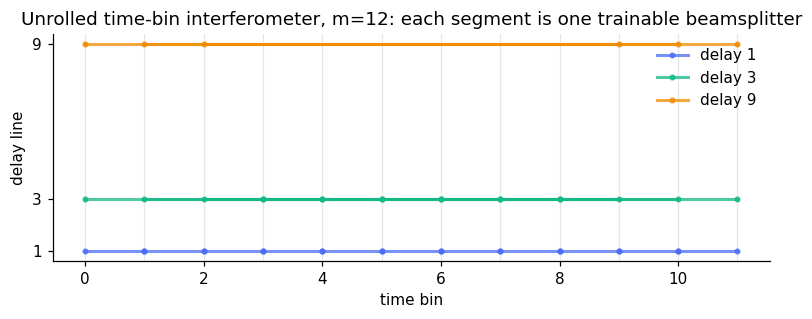

In [3]:
from lib.tbi import beamsplitter_layout, alternating_input, unitary, candidate_budget
import torch

M, DELAYS = 12, (1, 3, 9)
pairs = beamsplitter_layout(M, DELAYS)
print(f"m = {M}, delays = {DELAYS}: {len(pairs)} trainable beamsplitters")
print(f"input state |1,0,1,0,...> = {alternating_input(M)}  ({sum(alternating_input(M))} photons)")

fig, ax = plt.subplots(figsize=(7.2, 3.0))
for delay, colour in zip(DELAYS, [PALETTE["boson"], PALETTE["accent"], PALETTE["classical"]]):
    xs = [t for t in range(M - delay)]
    for order, t in enumerate(xs):
        ax.plot([t, t + delay], [delay, delay], color=colour, alpha=0.75, lw=2,
                marker="o", ms=3, label=f"delay {delay}" if order == 0 else None)
for bin_index in range(M):
    ax.axvline(bin_index, color="0.9", lw=0.8, zorder=0)
ax.set_yticks(DELAYS); ax.set_ylabel("delay line"); ax.set_xlabel("time bin")
ax.set_title(f"Unrolled time-bin interferometer, m={M}: each segment is one trainable beamsplitter")
ax.legend(loc="upper right", frameon=False); ax.grid(False)
plt.tight_layout(); plt.show()

### The budget claim, checked exactly

Appendix B bounds the candidates a run can touch by `N·S·(2Σᵢ(m−ℓᵢ) + 2m + 1)`. That formula
only comes out right if the strings drawn *while estimating gradients* count as candidates —
and ORCA's released solver does exactly that, tracking its best over every evaluation
including the shifted ones. The reproduction reproduces the bound term for term, which is
why C3 is an anchor test rather than a claim.

In [4]:
print(f"{'m':>4}{'candidates':>14}{'2^m':>16}{'coverage':>12}")
for m in (10, 15, 20, 25, 30):
    budget = candidate_budget(m, DELAYS, updates=200, samples=50)
    print(f"{m:>4}{budget:>14,}{2**m:>16,}{budget / 2**m:>11.2%}")
print("\nAt m <= 20 the algorithm may evaluate MORE candidates than the space contains.")
print("Those rows of Table I cannot separate a search strategy from no strategy at all,")
print("which is why a uniform random-search baseline is part of this reproduction.")

   m    candidates             2^m    coverage
  10       550,000           1,024  53710.94%
  15       950,000          32,768   2899.17%
  20     1,350,000       1,048,576    128.75%
  25     1,750,000      33,554,432      5.22%
  30     2,150,000   1,073,741,824      0.20%

At m <= 20 the algorithm may evaluate MORE candidates than the space contains.
Those rows of Table I cannot separate a search strategy from no strategy at all,
which is why a uniform random-search baseline is part of this reproduction.


## 4. What comes out of the circuit — and the quantity that turns out to matter

Below, the same interferometer is sampled four ways. Only the **click source** changes;
the circuit, the angles and everything downstream are identical.

| source | keeps | removes |
|---|---|---|
| `boson` | everything — the real thing | — |
| `shuffled_boson` | every per-mode marginal, exactly | the joint distribution only |
| `distinguishable` | photon number, per-photon columns of \|U\|² | multi-photon interference |
| `bernoulli` | per-mode click rates only | photon number, all correlation |

Watch the **mean clicks per shot**. The boson sampler *bunches* — photons arrive together —
so it lights up fewer modes than any interference-free source. Hold that thought.

boson            mean clicks  4.06 / 12   (33.8% of modes)
shuffled_boson   mean clicks  4.07 / 12   (33.9% of modes)
distinguishable  mean clicks  4.89 / 12   (40.8% of modes)
bernoulli        mean clicks  4.85 / 12   (40.4% of modes)


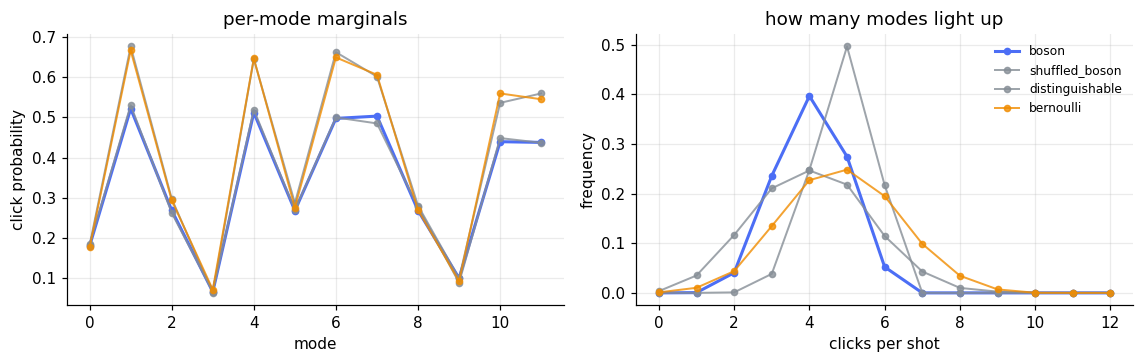


demo, m=12, 4000 shots, one random theta


In [5]:
from lib.sampler import ClickSource, SOURCES

theta = np.random.default_rng(0).random(len(pairs)) * 2 * np.pi
input_state = alternating_input(M)
shots = 4000

drawn, density = {}, {}
for name in SOURCES:
    clicks = ClickSource(M, DELAYS, input_state, source=name).draw(theta, shots, np.random.default_rng(1))
    drawn[name] = clicks
    density[name] = clicks.mean()
    print(f"{name:<16} mean clicks {clicks.sum(1).mean():5.2f} / {M}   ({clicks.mean():.1%} of modes)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for name in SOURCES:
    colour = PALETTE["boson"] if name == "boson" else PALETTE["classical"] if name == "bernoulli" else PALETTE["control"]
    axes[0].plot(drawn[name].mean(0), marker="o", ms=4, label=name, color=colour,
                 lw=2 if name == "boson" else 1.3, alpha=1 if name == "boson" else 0.8)
    counts = np.bincount(drawn[name].sum(1), minlength=M + 1)
    axes[1].plot(counts / shots, marker="o", ms=4, label=name, color=colour,
                 lw=2 if name == "boson" else 1.3, alpha=1 if name == "boson" else 0.8)
axes[0].set_xlabel("mode"); axes[0].set_ylabel("click probability"); axes[0].set_title("per-mode marginals")
axes[1].set_xlabel("clicks per shot"); axes[1].set_ylabel("frequency"); axes[1].set_title("how many modes light up")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
print("\ndemo, m=12, 4000 shots, one random theta")

## 5. Training it

One update: sample, flip, estimate both gradients, step. The cost is dominated by the
parameter-shift rule — `2K` extra circuit evaluations for `K` angles, so **125 circuit
evaluations per update at m = 25 of which 124 exist only to measure a derivative**.

The run below is a reduced demo (`m = 10`, 60 updates, 20 shots) so it finishes in seconds.
Even so it finds the exact optimum, which dynamic programming gives us independently.

knapsack m=10, seed 0: 10 items, capacity 73
exact optimum by dynamic programming: -60



best found: -60   OPTIMAL
candidates evaluated: 66,000 = Appendix B bound (66,000)? True
wall clock: 3.5 s   [demo: reduced from the paper's N=200, S=50]


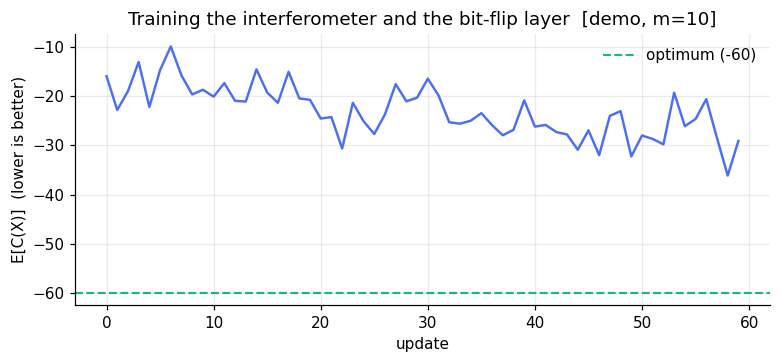

In [6]:
from lib.problems import build_problem
from lib.bbs import BosonicBinarySolver

instance, cost_batch, optimum = build_problem("knapsack", 10, seed=0)
print(f"knapsack m=10, seed 0: {len(instance['values'])} items, capacity {instance['capacity']}")
print(f"exact optimum by dynamic programming: {optimum:.0f}")

began = time.time()
solver = BosonicBinarySolver(10, delays=DELAYS, updates=60, samples=20, seed=0)
result = solver.solve(cost_batch)
print(f"\nbest found: {result['best_cost']:.0f}   {'OPTIMAL' if abs(result['best_cost'] - optimum) < 1e-9 else 'suboptimal'}")
print(f"candidates evaluated: {result['evaluations']:,} = Appendix B bound ({result['budget']:,})? "
      f"{result['evaluations'] == result['budget']}")
print(f"wall clock: {time.time() - began:.1f} s   [demo: reduced from the paper's N=200, S=50]")

fig, ax = plt.subplots()
ax.plot(result["history"], color=PALETTE["boson"], lw=1.6)
ax.axhline(optimum, color=PALETTE["accent"], ls="--", lw=1.4, label=f"optimum ({optimum:.0f})")
ax.set_xlabel("update"); ax.set_ylabel("E[C(X)]  (lower is better)")
ax.set_title("Training the interferometer and the bit-flip layer  [demo, m=10]")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

### Does the photonic circuit matter? (claim C7)

The paper's own ablation: freeze `θ` at its random initialisation and let only the bit-flip
layer train. At full scale the answer is emphatic — **96% → 21% at m=25, 73% → 3% at m=30**,
discordant 0/75 and 0/70, McNemar z = 8.5 and 8.3.

So the trainable interferometer is unambiguously load-bearing. Which makes the next section
more surprising, not less.

## 6. The MerLin photonic extension: exact gradients

The parameter-shift rule is a *hardware* technique — on a real device you cannot
differentiate the optics, so you re-measure at shifted angles. In simulation you can:
[MerLin](https://merlinquantum.ai) builds the interferometer's output distribution as a
differentiable function of `θ`, so the same objective is minimised by autograd with **one**
circuit evaluation per update instead of `1 + 2K`.

The physics is untouched — same unrolled circuit, same `|1,0,1,0,…⟩`, same threshold
detectors, same trainable flip layer. Only the derivative estimator changes.

Two counters are reported and they are **not** interchangeable: `candidates_sampled` is what
a hardware run would evaluate, and `simulator_cost_evaluations` is what forming the exact
expectation touches. The second is a simulation-only capability, not a speedup you could
take to a chip.

exact distribution over all 2^10 click patterns, sums to 1.0000000000



best found: -59   suboptimal
circuit evaluations :        60   (parameter-shift path: 2,100)
candidates sampled  :     1,200   (parameter-shift path: 66,000)
wall clock: 1.9 s


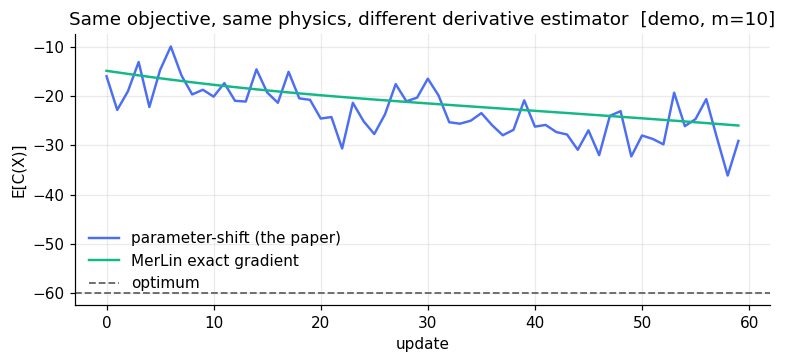

In [7]:
from lib.bbs_merlin import MerlinBinarySolver

began = time.time()
merlin_solver = MerlinBinarySolver(10, delays=DELAYS, updates=60, flip_samples=20, seed=0)
probabilities = merlin_solver.click_probabilities()
print(f"exact distribution over all 2^10 click patterns, sums to {float(probabilities.sum().detach()):.10f}")

merlin_result = merlin_solver.solve(cost_batch)
print(f"\nbest found: {merlin_result['best_cost']:.0f}   "
      f"{'OPTIMAL' if abs(merlin_result['best_cost'] - optimum) < 1e-9 else 'suboptimal'}")
print(f"circuit evaluations : {merlin_result['circuit_evaluations']:>9,}   "
      f"(parameter-shift path: {60 * (1 + 2 * len(beamsplitter_layout(10, DELAYS))):,})")
print(f"candidates sampled  : {merlin_result['candidates_sampled']:>9,}   "
      f"(parameter-shift path: {result['evaluations']:,})")
print(f"wall clock: {time.time() - began:.1f} s")

fig, ax = plt.subplots()
ax.plot(result["history"], color=PALETTE["boson"], lw=1.6, label="parameter-shift (the paper)")
ax.plot(merlin_result["history"], color=PALETTE["accent"], lw=1.6, label="MerLin exact gradient")
ax.axhline(optimum, color="0.4", ls="--", lw=1.2, label="optimum")
ax.set_xlabel("update"); ax.set_ylabel("E[C(X)]")
ax.set_title("Same objective, same physics, different derivative estimator  [demo, m=10]")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 7. Fair baselines — and what they reveal about the benchmark

The paper compares against simulated annealing and hill climbing but never says what
*evaluation budget* those baselines received. The only comparison that tests the claim is one
where every method may call the cost function the same number of times. So here every
baseline gets exactly the Appendix B budget — and a **uniform random search** is added, as
the honest floor.

In [8]:
from lib.baselines import BASELINES

DEMO_M, DEMO_INSTANCES, DEMO_N, DEMO_S = 18, 24, 20, 10
demo_budget = candidate_budget(DEMO_M, DELAYS, updates=DEMO_N, samples=DEMO_S)
print(f"demo: m={DEMO_M}, {DEMO_INSTANCES} instances, budget {demo_budget:,} "
      f"= {demo_budget / 2**DEMO_M:.1%} of the space\n")

scores = {}
for name, routine in BASELINES.items():
    hits, began = 0, time.time()
    for seed in range(DEMO_INSTANCES):
        _, costs, best = build_problem("knapsack", DEMO_M, seed)
        found = routine(costs, DEMO_M, demo_budget, np.random.default_rng(seed))
        hits += abs(found["best_cost"] - best) < 1e-9
    scores[name] = 100 * hits / DEMO_INSTANCES
    print(f"  {name:<22} {scores[name]:5.1f}% optimal   ({time.time() - began:.1f} s)")

print("\n[demo: at 9% coverage the methods separate, unlike m=20 at the paper's full budget")
print(" where the budget exceeds the whole space and everything scores ~100%.")
print(" Random search collapsing is the point: when coverage is small, strategy matters.]")

demo: m=18, 24 instances, budget 23,800 = 9.1% of the space



  simulated_annealing     87.5% optimal   (4.6 s)


  hill_climbing           95.8% optimal   (0.6 s)
  random_search           12.5% optimal   (0.1 s)

[demo: at 9% coverage the methods separate, unlike m=20 at the paper's full budget
 where the budget exceeds the whole space and everything scores ~100%.
 Random search collapsing is the point: when coverage is small, strategy matters.]


At full scale, **m = 20, 100 instances, matched budget**:

| method | % optimal | the paper reports |
|---|---|---|
| simulated annealing | 100% | 100% |
| hill climbing | **100%** | **84%** |
| uniform random search | **81%** | not run |
| BBS | 99% | 98% |

Two things fall out. The budget at m=20 is **1.29× the entire solution space**, and uniform
sampling alone reaches 81% — so that row of Table I cannot distinguish a search strategy from
none. And the paper's hill climbing, at 84%, sits *below* random sampling at the solver's own
budget: a local search losing to random guessing is hard to explain unless the baselines were
given far fewer evaluations than the solver.

## 8. The result that took the most work: it is the click density

Section 4 showed the boson sampler lighting up fewer modes than the interference-free
sources. That is bunching, and it turns out to be the whole story on knapsack.

`bernoulli@r` scales the per-mode click rate by `r` and changes **nothing else** — same
circuit, same angles, same budget. Sweeping `r` sweeps click density in isolation.

In [9]:
from lib.bbs_gpu import solve_batch
from lib.problems_torch import build_batch

LADDER_M, LADDER_INSTANCES, LADDER_N, LADDER_S = 18, 48, 20, 10
seeds = list(range(LADDER_INSTANCES))
batched_cost, optima = build_batch("knapsack", LADDER_M, seeds, torch.device("cpu"))

ladder, began = [], time.time()
for rate in (0.8, 1.0, 1.2, 1.4):
    out = solve_batch(batched_cost, LADDER_M, seeds, delays=DELAYS, updates=LADDER_N,
                      samples=LADDER_S, source="bernoulli", rate_scale=rate, device=torch.device("cpu"))
    error = 100 * float(np.mean([abs(b - o) / abs(o) for b, o in zip(out["best_cost"], optima)]))
    density = float(np.mean(out["mean_clicks"])) / LADDER_M
    ladder.append((rate, density, error))
    print(f"  bernoulli@{rate:<4} density {density:5.1%}   mean error {error:.3f}%")

# where does the boson sampler sit on this axis? Sampling its density is cheap;
# training it on CPU at this size is not (4 s per instance), so its *performance*
# is quoted from the full-scale runs rather than measured here.
boson_theta = np.random.default_rng(0).random(len(beamsplitter_layout(LADDER_M, DELAYS))) * 2 * np.pi
boson_clicks = ClickSource(LADDER_M, DELAYS, alternating_input(LADDER_M), source="boson").draw(
    boson_theta, 2000, np.random.default_rng(2))
boson_density = boson_clicks.mean()
print(f"\n  boson sampler sits at density {boson_density:.1%} -- below every rung above")
print(f"[demo, m={LADDER_M}, {LADDER_INSTANCES} instances, reduced budget -- {time.time() - began:.0f} s]")

  bernoulli@0.8  density 34.4%   mean error 3.278%


  bernoulli@1.0  density 43.1%   mean error 2.413%


  bernoulli@1.2  density 51.4%   mean error 2.142%


  bernoulli@1.4  density 59.1%   mean error 1.927%

  boson sampler sits at density 35.3% -- below every rung above
[demo, m=18, 48 instances, reduced budget -- 3 s]


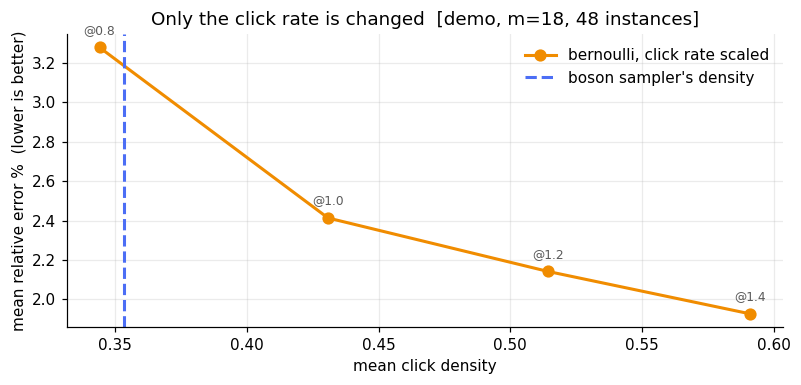

Bunching parks the boson source at the left of an axis that moves performance.


In [10]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot([d for _, d, _ in ladder], [e for _, _, e in ladder], marker="o", ms=7,
        color=PALETTE["classical"], lw=2, label="bernoulli, click rate scaled")
for rate, dens, err in ladder:
    ax.annotate(f"@{rate}", (dens, err), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color="0.35")
ax.axvline(boson_density, color=PALETTE["boson"], ls="--", lw=2, label="boson sampler's density")
ax.set_xlabel("mean click density"); ax.set_ylabel("mean relative error %  (lower is better)")
ax.set_title(f"Only the click rate is changed  [demo, m={LADDER_M}, {LADDER_INSTANCES} instances]")
ax.legend(frameon=False); plt.tight_layout(); plt.show()
print("Bunching parks the boson source at the left of an axis that moves performance.")

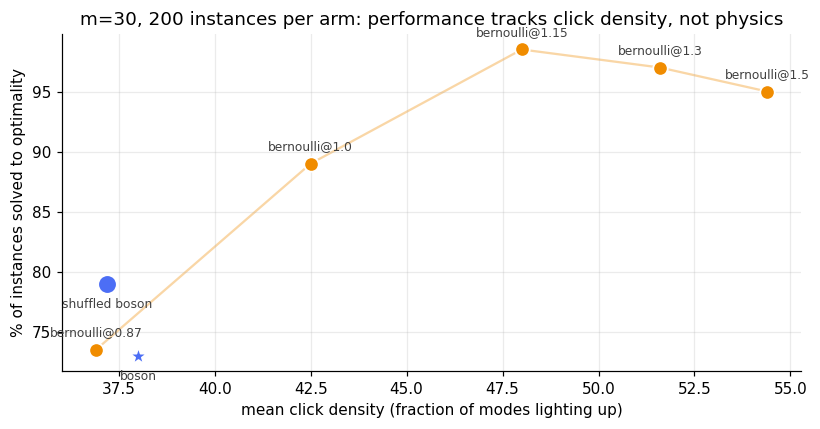

full scale, from results/gpu_results_*.jsonl


In [11]:
full = {  # m=30, 200 instances per arm, paper hyperparameters -- results/gpu_results_*.jsonl
    "bernoulli@0.87": (36.9, 73.5), "boson": (38.0, 73.0), "shuffled boson": (37.2, 79.0),
    "bernoulli@1.0": (42.5, 89.0), "bernoulli@1.15": (48.0, 98.5),
    "bernoulli@1.3": (51.6, 97.0), "bernoulli@1.5": (54.4, 95.0),
}
fig, ax = plt.subplots(figsize=(7.6, 4.0))
for name, (dens, opt) in full.items():
    quantum = name in ("boson", "shuffled boson")
    ax.scatter(dens, opt, s=150 if quantum else 90, zorder=3,
               color=PALETTE["boson"] if quantum else PALETTE["classical"],
               marker="*" if name == "boson" else "o",
               edgecolor="white", linewidth=1.2)
    ax.annotate(name, (dens, opt), textcoords="offset points", xytext=(0, -16 if quantum else 9),
                ha="center", fontsize=8, color="0.25")
classical = sorted(v for k, v in full.items() if k not in ("boson", "shuffled boson"))
ax.plot([c[0] for c in classical], [c[1] for c in classical], color=PALETTE["classical"], alpha=0.35, lw=1.5, zorder=1)
ax.set_xlabel("mean click density (fraction of modes lighting up)")
ax.set_ylabel("% of instances solved to optimality")
ax.set_title("m=30, 200 instances per arm: performance tracks click density, not physics")
plt.tight_layout(); plt.show()
print("full scale, from results/gpu_results_*.jsonl")

The paired statistics, at full scale:

- **at matched density the boson sampler and independent Bernoulli clicks are
  indistinguishable** — boson (38.0%) vs `bernoulli@0.87` (36.9%): discordant 18/19, z = 0.00;
- moving density alone moves everything — `0.87 → 1.5`: discordant 6/49, **z = 5.66**;
- destroying the boson joint distribution while keeping its marginals (`shuffled boson`)
  never hurts, at any size, in either problem family.

Put beside C7 — freezing `θ` is catastrophic — the picture is coherent and specific:
**the trained interferometer matters enormously, and what it contributes reaches the
optimiser through the per-mode marginals of `|U(θ)|²`.** Multi-photon interference is not
measurably contributing, and bunching actively costs the boson source by parking it at the
low end of a density axis the bit-flip layer cannot correct (raising `lr_alpha` tenfold moves
it one point).

### Where this stops being true

On **TSP** a candidate is an integer that gets Lehmer-decoded into a permutation, so the
number of ones in the string means nothing. Prediction: the density ladder should be flat.
It is — at m=29, 100–200 instances per arm:

| arm | clicks/m | % optimal | mean error |
|---|---|---|---|
| shuffled boson | 38.3% | 3.5 | 6.385 |
| **boson** | 38.6% | **7.0** | **5.589** |
| bernoulli@1.0 | 44.0% | 3.0 | 5.600 |
| distinguishable | 44.1% | 8.5 | 5.317 |

Every comparison null (\|z\| ≤ 0.8). So the claim is bounded exactly where it should be:
*click density governs performance where the binary encoding gives it meaning.* It is a fact
about the encoding, not a universal law — and on the family where it does not apply, no
source beats any other either.

(The paper's own TSP row is reproduced and exceeded: 7% optimal and 5.59% error against its
2% and 6.58%.)

## 9. What can and cannot be concluded

**Supported.** The paper's knapsack and TSP results reproduce (m=20: 99% vs 98%; m=25: 96% vs
99%; TSP m=29: 7% vs 2%). Its candidate-budget accounting is exact. Its own ablation holds
decisively: the trainable photonic circuit is essential.

**Not supported.** The premise that the *boson sampler* is the active ingredient. At matched
click density no source outperforms another, and the joint distribution can be destroyed
without cost. This is the control the paper does not run — its ablations remove *training*,
not *quantumness*.

**Observations for the authors.** Three of five knapsack sizes give every method a budget
exceeding the whole solution space. And the reported hill-climbing baseline underperforms
uniform random search at the solver's budget, which suggests the baselines were not matched.

**Unresolved.** m=30 comes out at 73% against the paper's 93%. The leading suspect is the
instance generator, which the paper does not publish — knapsack difficulty at fixed size is
very sensitive to the capacity fraction and to value/weight correlation. Implementation
confidence is nevertheless HIGH: the candidate count matches Appendix B term for term, the
loop-topology unitary reproduces ORCA's released simulator to 1e-12, and the GPU sampler
matches Perceval within Monte-Carlo error.

**Photonic assessment.** The architecture maps cleanly onto MerLin and is cheap to simulate,
and exact gradients remove the estimator that dominates the paper's own budget. But on the
evidence here the quantum sampler is not the active ingredient in the regime tested. The
natural follow-up is a loss model — and it now carries a sharp prediction: loss lowers click
density, so it should move the boson arm *monotonically down the same ladder*. If it did not,
the density account would be wrong.